In [11]:
import model_template as model
import pandas as pd
import numpy as np
import pollux as plx
from pollux.models.transforms import LinearTransform
import matplotlib.pyplot as plt
from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [12]:
datafile_path = '/Users/honeyeah/Codes/LuxProject/data/giants_rel_most_rel.pkl'
df_stars = pd.read_pickle(datafile_path)
n_stars = len(df_stars)
n_latents = 20
labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h']

In [13]:
predict_train_values, train_data, predict_test_values, test_data, predict_test_values_flux, all_data = model.sdss_gaia_model(
    path_to_pickle=datafile_path,
    label_names=labels,
    n_stars=n_stars,
    n_latents=n_latents,
    which_output='all'
)

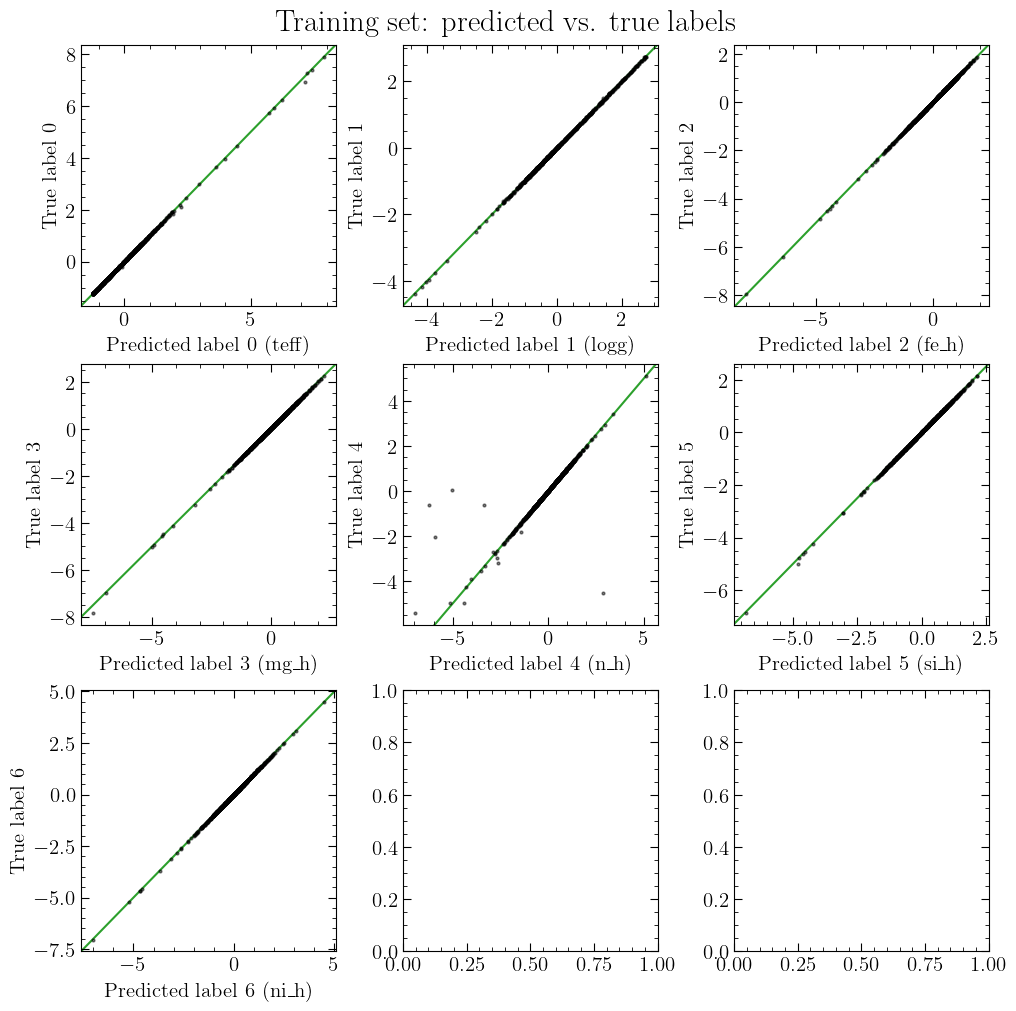

In [ ]:
fig_xsize=10
fig_ysize=10

labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h', 'ca_h', 'ce_h']

pt_style = {"ls": "none", "ms": 2.0, "alpha": 0.5, "marker": "o", "color": "k"}

fig, axes = plt.subplots(3, 3, figsize=(fig_xsize, fig_ysize), layout="constrained")
axes = axes.flatten()
for i in range(predict_train_values["label"].shape[1]):
    axes[i].plot(
        predict_train_values["label"][:, i], train_data["label"].data[:, i], **pt_style
    )
    axes[i].set(xlabel=f"Predicted label {i} ({labels[i]})", ylabel=f"True label {i}")
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle("Training set: predicted vs. true labels", fontsize=22)

plt.show()

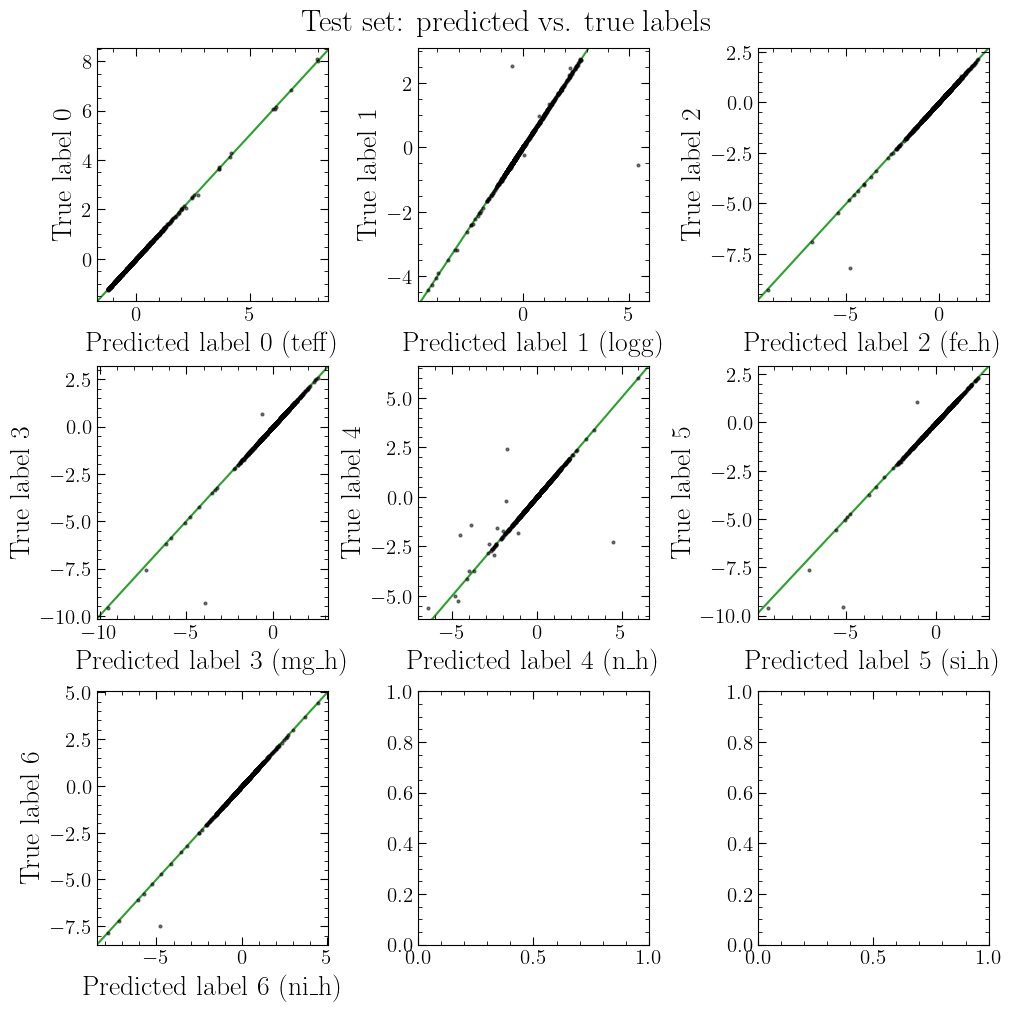

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(fig_xsize, fig_ysize), layout="constrained")
axes = axes.flatten()
for i in range(predict_test_values["label"].shape[1]):
    axes[i].plot(
        predict_test_values["label"][:, i], test_data["label"].data[:, i], **pt_style
    )
    axes[i].set_xlabel(f"Predicted label {i} ({labels[i]})", fontsize=20)
    axes[i].set_ylabel(f"True label {i}", fontsize=20)
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle("Test set: predicted vs. true labels", fontsize=22)

plt.show()

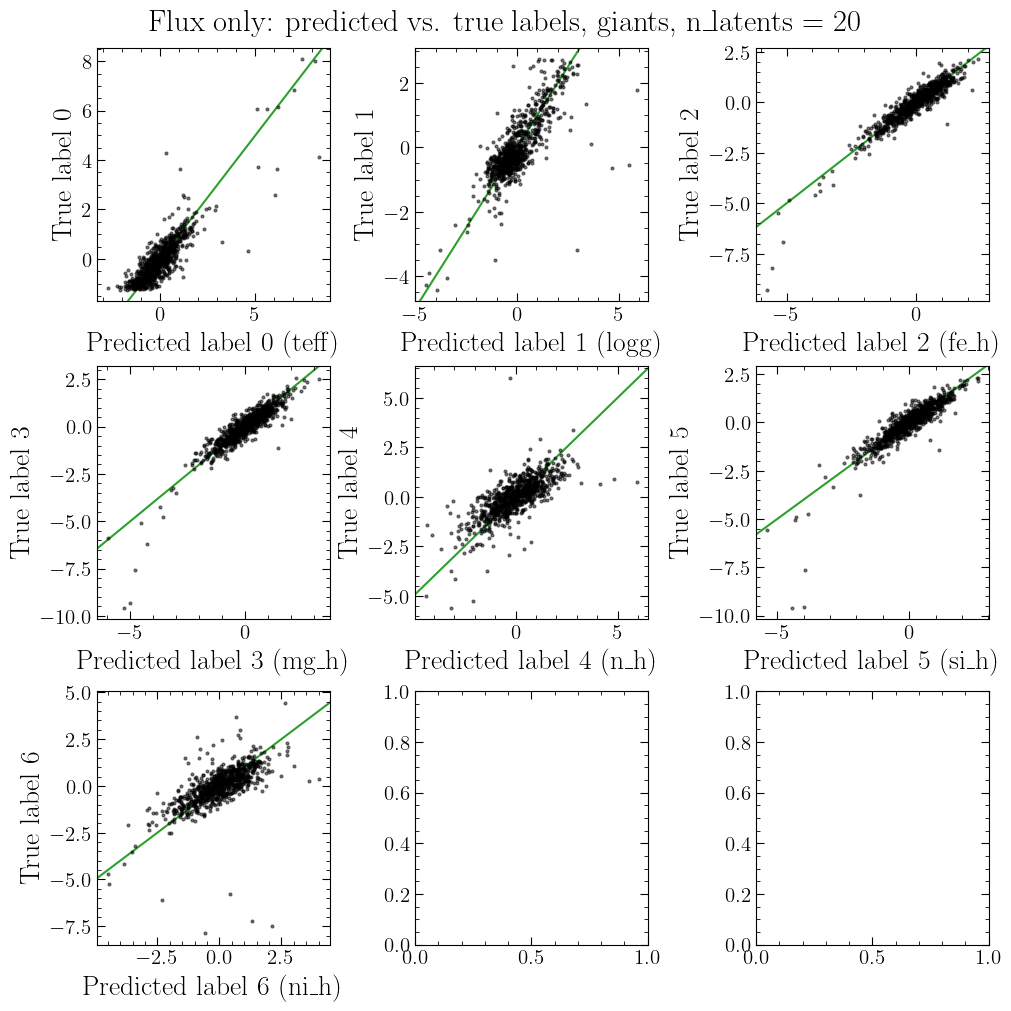

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(fig_xsize, fig_ysize), layout="constrained")
axes = axes.flatten()
for i in range(predict_test_values_flux["label"].shape[1]):
    axes[i].plot(
        predict_test_values_flux["label"][:, i], test_data["label"].data[:, i], **pt_style
    )
    axes[i].set_xlabel(f"Predicted label {i} ({labels[i]})", fontsize=20)
    axes[i].set_ylabel(f"True label {i}", fontsize=20)
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle(f"Flux only: predicted vs. true labels, giants, n_latents = {n_latents}", fontsize=22)

plt.show()

In [17]:
predict_test_unprocessed = test_data.unprocess(predict_test_values_flux)
test_data_unprocessed = all_data[n_stars // 2:]

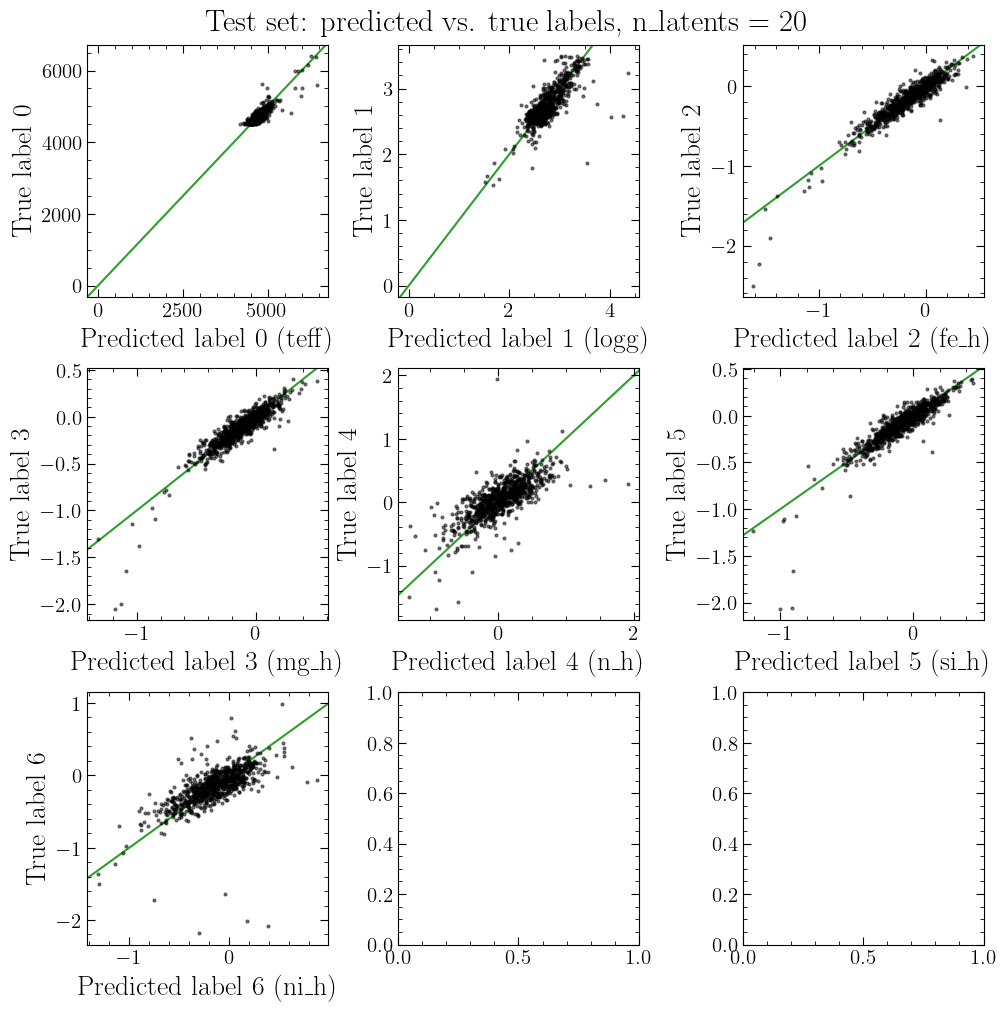

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(fig_xsize, fig_ysize), layout="constrained")
axes = axes.flatten()
for i in range(len(labels)):
    axes[i].plot(
        predict_test_unprocessed["label"].data[:, i], test_data_unprocessed["label"].data[:, i], **pt_style
    )
    axes[i].set_xlabel(f"Predicted label {i} ({labels[i]})", fontsize=20)
    axes[i].set_ylabel(f"True label {i}", fontsize=20)
    axes[i].axline([0, 0], slope=1, color="tab:green", zorder=-100)
_ = fig.suptitle(f"Test set: predicted vs. true labels, n_latents = {n_latents}", fontsize=22)
plt.show()

In [19]:
results = {}

for i, name in enumerate(labels):
    y_true = test_data_unprocessed["label"].data[:, i]
    y_pred = predict_test_unprocessed["label"].data[:, i]

    res = y_pred - y_true

    results[name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": res,
        "std_res": np.std(res),
        "RMSE": np.sqrt(np.mean(res**2)),
        "MAE": np.mean(np.abs(res)),
        "Bias": np.mean(res),
        "R2": 1 - np.sum(res**2) / np.sum((y_true - np.mean(y_true))**2),
    }


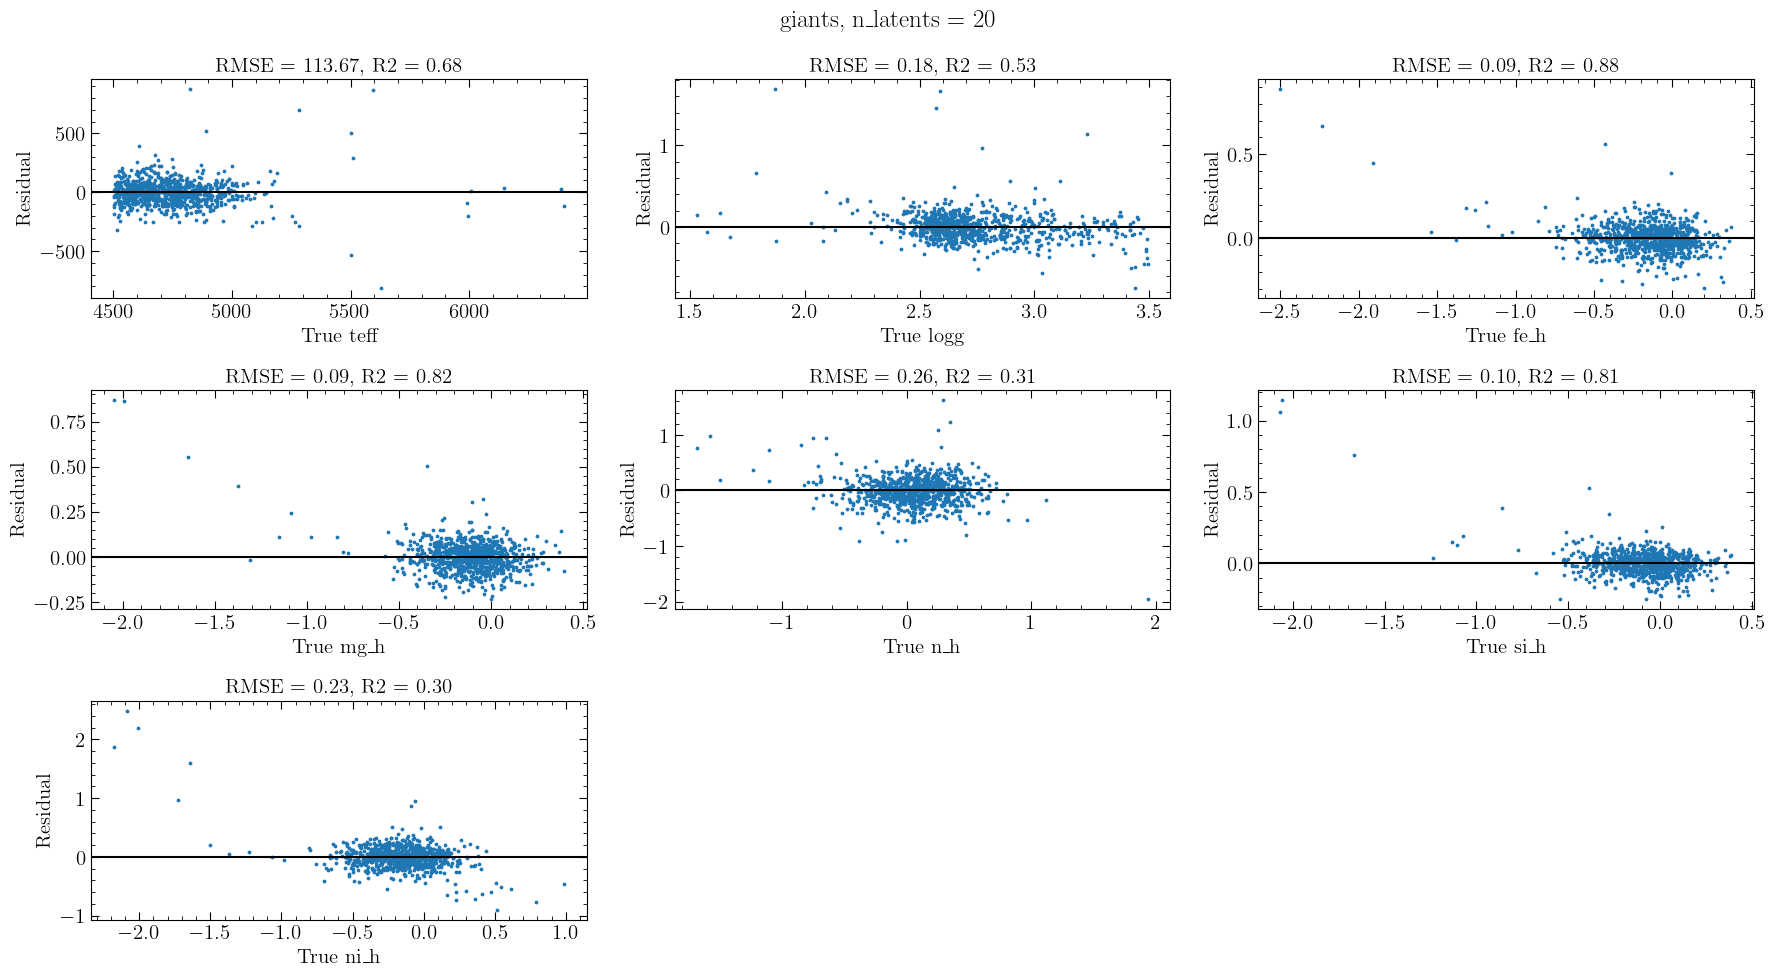

In [20]:
plt.figure(figsize=(18,10))

for i in range(len(labels)):
    name = labels[i]
    plt.subplot(3,3,i+1)
    plt.scatter(results[name]["y_true"], results[name]["residuals"], s = 3)
    plt.axhline(0, color="k")
    plt.xlabel(f"True {name}")
    plt.ylabel("Residual")
    plt.title(f"RMSE = {results[name]["RMSE"]:.2f}, R2 = {results[name]["R2"]:.2f}")

plt.suptitle(f"giants, n_latents = {n_latents}")
plt.tight_layout()

In [35]:
total_rmse = np.sqrt(np.mean((predict_test_unprocessed["label"].data - test_data_unprocessed["label"].data) ** 2))